<div class="alert alert-block alert-info" 
     style="background-color:#eefbff; 
            border-left:5px solid #06b6d4; 
            padding:14px; 
            border-radius:8px;">
    
# **📊1: Understand The Data**

## Load and preview the dataset

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st
import warnings
warnings.filterwarnings('ignore')

In [2]:
os.chdir('C:\Carrer247 Project\Statistics mini project\Dataset')

In [3]:
os.listdir()

['US_Customer_Insights_Dataset.csv']

In [4]:
df = pd.read_csv('US_Customer_Insights_Dataset.csv')

In [5]:
df.head()

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103


In [6]:
df.shape

(10675, 12)

### Check data types

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB


### Convert Date Columns

In [8]:
df['JoinDate'] = pd.to_datetime(df['JoinDate'])
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])


In [9]:
df['MonthlySpend'] = df['MonthlySpend'].astype('int')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CustomerID                10675 non-null  object        
 1   Name                      10675 non-null  object        
 2   State                     10675 non-null  object        
 3   Education                 10675 non-null  object        
 4   Gender                    10675 non-null  object        
 5   Age                       10675 non-null  int64         
 6   Married                   10675 non-null  object        
 7   NumPets                   10675 non-null  int64         
 8   JoinDate                  10675 non-null  datetime64[ns]
 9   TransactionDate           10675 non-null  datetime64[ns]
 10  MonthlySpend              10675 non-null  int64         
 11  DaysSinceLastInteraction  10675 non-null  int64         
dtypes: datetime64[ns](

### Check Unique Values

In [11]:
df.nunique()

CustomerID                  1000
Name                         990
State                         10
Education                      5
Gender                         3
Age                           63
Married                        2
NumPets                        5
JoinDate                     731
TransactionDate             1605
MonthlySpend                1085
DaysSinceLastInteraction    1605
dtype: int64

### Check Missing Values

In [12]:
df.isna().sum()

CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

## Categorical vs Numerical Variables

### Categorical Variables:
* CustomerID
* Name
* State
* Education
* Gender
* Married

### Numerical Variables:
* Age
* NumPets
* MonthlySpend
* DaysSinceLastInteraction

### Date Variables:
* JoinDate
* TransactionDate


<div class="alert alert-block alert-info" 
     style="background-color:#eefbff; 
            border-left:5px solid #06b6d4; 
            padding:14px; 
            border-radius:8px;"> 
    
# **📊 2: Descriptive Statistics**

## Numerical Statistics

In [13]:
# Mean, Median, Standard Deviation
df[['Age','MonthlySpend','DaysSinceLastInteraction']].agg(['mean','median','std'])

,Age,MonthlySpend,DaysSinceLastInteraction
mean,49.474567,331.114473,538.469883
median,49.000000,282.000000,445.000000
std,18.221365,225.798348,398.766747


## 🔥 Insight

👉 The average customer age is 49.47 years, with a median of 49, indicating a well-balanced age distribution without significant skewness. This suggests the customer base is primarily middle-aged.

👉 The average monthly spend is 331.11, while the median is lower at 282, indicating a slight right-skew in spending. This suggests the presence of a smaller group of high-value customers contributing disproportionately to revenue.

👉 The standard deviation of monthly spend (225.80) is relatively high, showing significant variability in customer spending behavior, which highlights the need for customer segmentation.

👉 The average Days Since Last Interaction is 538 days, with a median of 445 days, indicating that many customers have not interacted recently. This suggests potential customer inactivity or churn risk.

👉 The high standard deviation (398.77) in Days Since Last Interaction further confirms a wide gap between recently active and inactive customers, making it important to target re-engagement strategies.

## Mode for Categorical Variables

In [14]:
# Mode for categorical columns
df[['Gender','Education','Married']].mode()

,Gender,Education,Married
0,Male,Master,No


## 🔥 Insight 

👉 The most common gender in the dataset is Male, indicating that male customers form a larger portion of the customer base.

👉 Most customers have a Master’s level education, suggesting a highly educated customer segment.

👉 The majority of customers are not married, which may influence purchasing behavior and lifestyle-based preferences.

<div class="alert alert-block alert-info" 
     style="background-color:#eefbff; 
            border-left:5px solid #06b6d4; 
            padding:14px; 
            border-radius:8px;"> 
    
# **📊3: Data Visualization**


## **Histograms (Age & Monthly Spend)**

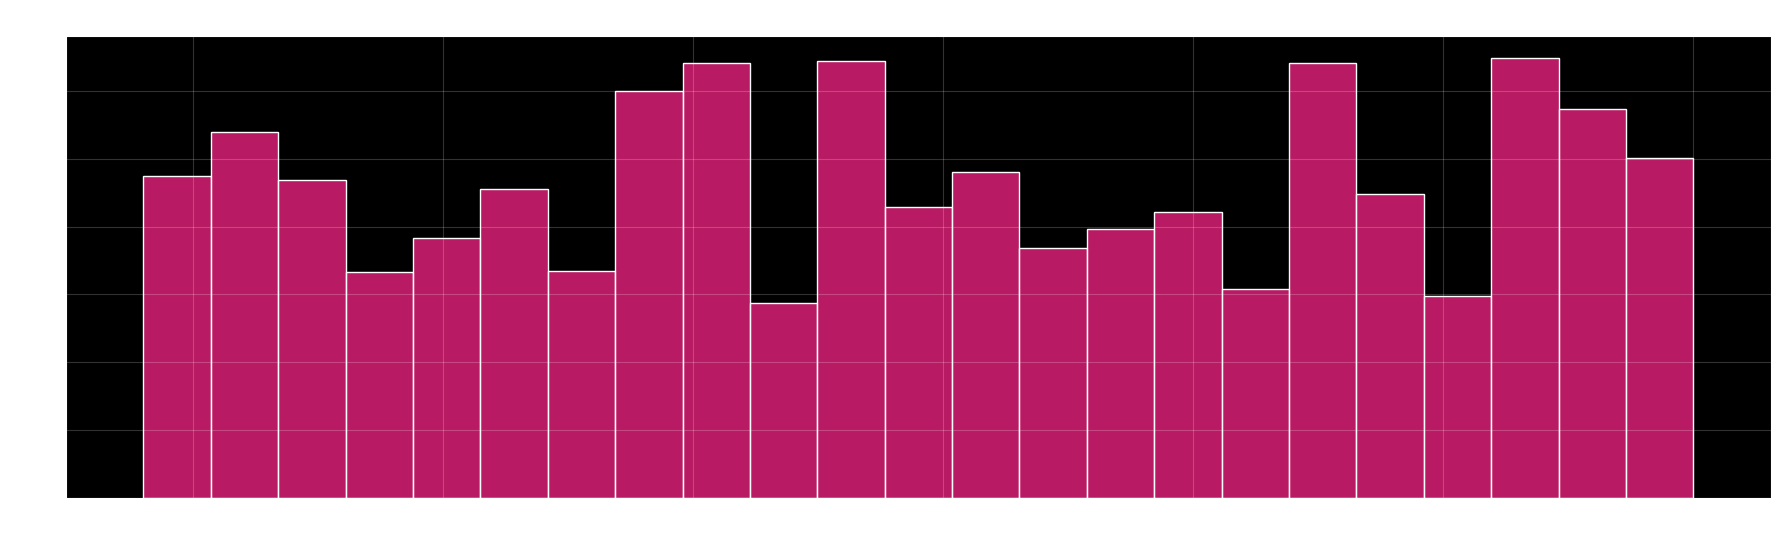

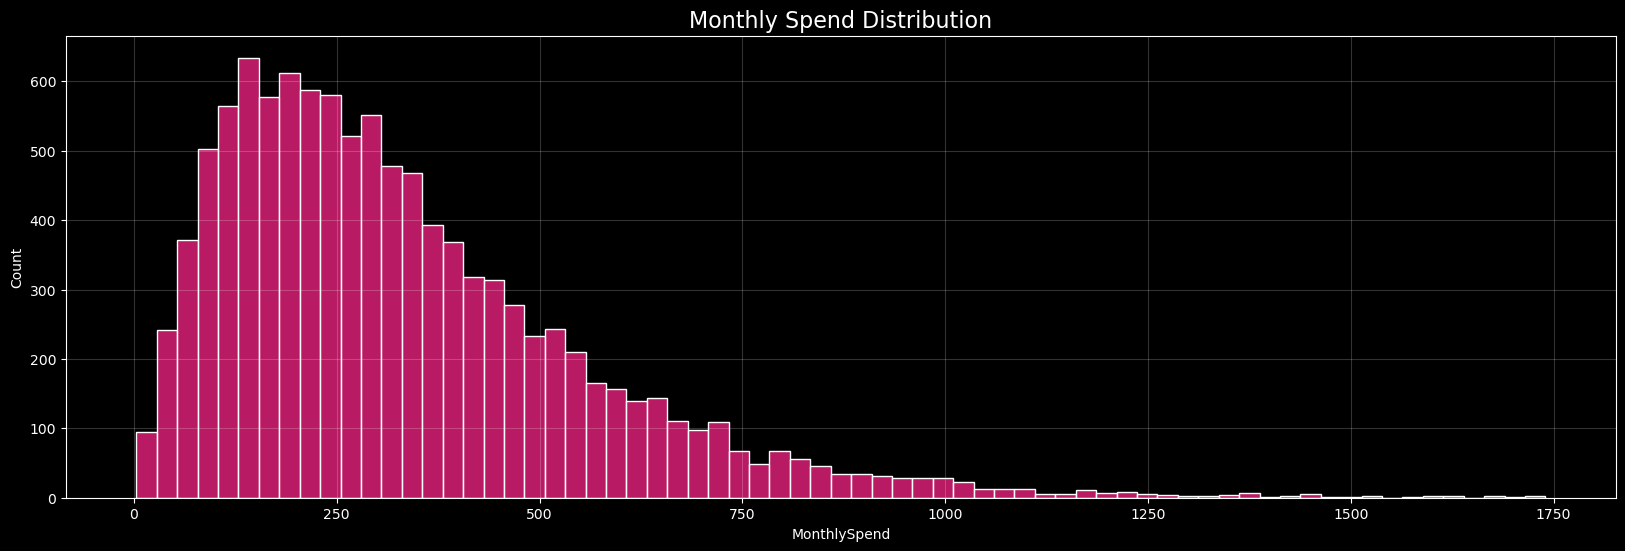

In [15]:
# Age Distribution
plt.figure(figsize=(22,6))
plt.style.use("dark_background")
sns.histplot(df['Age'], color="#F72585")
plt.title("Age Distribution", color="white", fontsize=16)
plt.grid(alpha=0.2)
plt.show()

# Monthly Spend Distribution
plt.figure(figsize=(20,6))
plt.style.use("dark_background")
sns.histplot(df['MonthlySpend'], color="#F72585")
plt.title("Monthly Spend Distribution", color="white", fontsize=16)
plt.grid(alpha=0.2)
plt.show()

<div class="alert alert-block alert-success" 
     style="background-color:#edf7f0; 
            border-left:5px solid #22c55e; 
            padding:14px; 
            border-radius:8px;">

##  Age Histogram
### Observation:
The age distribution appears fairly balanced across different age groups, with most customers falling between 30 and 60 years of age.  
There are relatively fewer customers at the extreme younger and older age ranges.

---

##  Monthly Spend Histogram
### Observation:
Monthly spending is positively skewed, meaning most customers have moderate spending levels while a smaller number of customers spend significantly more.  
This indicates the presence of high-value customers in the dataset.

---





## **Boxplots (Age & Monthly Spend)**

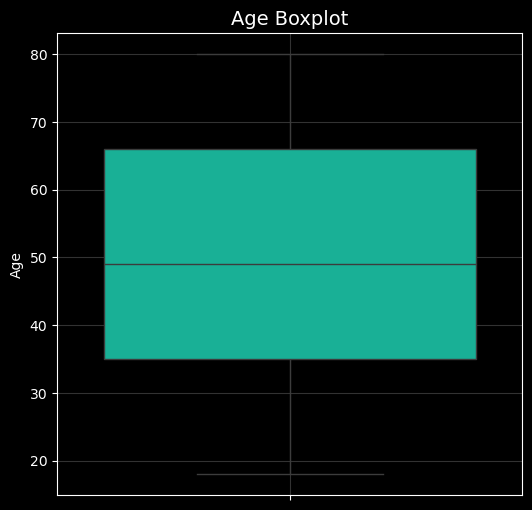

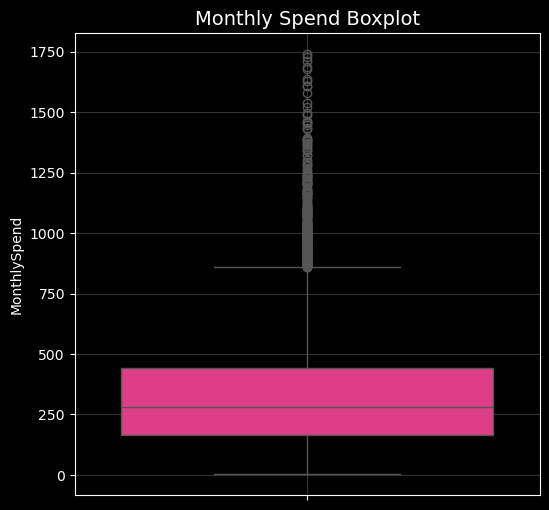

In [16]:
# Age Boxplot
plt.figure(figsize=(6,6))
plt.style.use("dark_background")
sns.boxplot(y=df['Age'], color="#00C9A7")
plt.title("Age Boxplot", color="white", fontsize=14)
plt.grid(alpha=0.2)
plt.show()

# Monthly Spend Boxplot
plt.figure(figsize=(6,6))
sns.boxplot(y=df['MonthlySpend'], color="#F72585")
plt.title("Monthly Spend Boxplot", color="white", fontsize=14)
plt.grid(alpha=0.2)
plt.show()

<div class="alert alert-block alert-success" 
     style="background-color:#edf7f0; 
            border-left:5px solid #22c55e; 
            padding:14px; 
            border-radius:8px;">

##  Age Boxplot
### Observation:
The boxplot shows that customer ages are fairly evenly distributed with limited extreme outliers.  
Most customer ages are concentrated within the middle age range.

---

##  Monthly Spend Boxplot
### Observation:
Several high-spending outliers are visible in the monthly spending data.  
This suggests that a small group of customers contributes significantly higher revenue compared to the average customer.

---


## **Bar chart for Gender, Education, State**

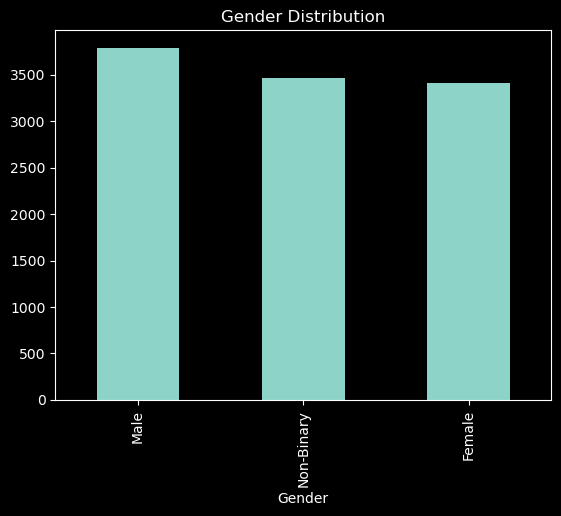

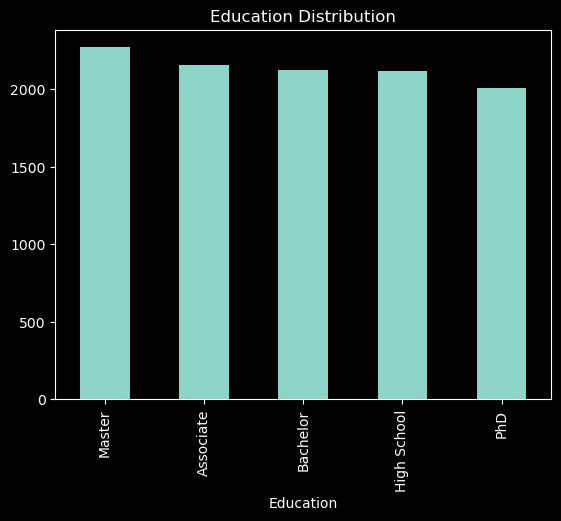

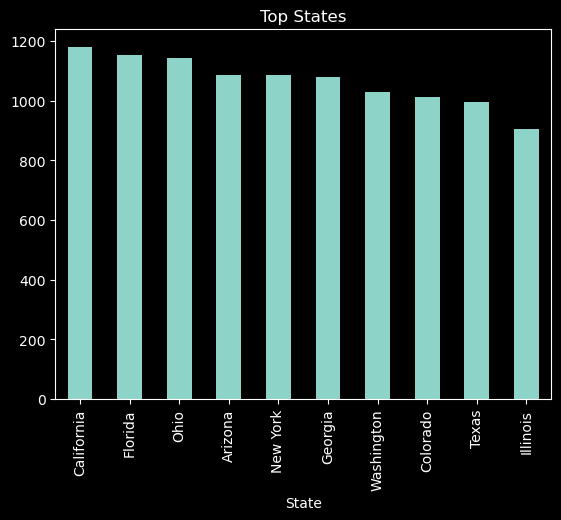

In [17]:
# Gender
df['Gender'].value_counts().plot(kind='bar', title="Gender Distribution")
plt.style.use("dark_background")
plt.show()

# Education
df['Education'].value_counts().plot(kind='bar', title="Education Distribution")
plt.style.use("dark_background")
plt.show()

# State (Top 10 for clarity)
df['State'].value_counts().head(10).plot(kind='bar', title="Top States")
plt.style.use("dark_background")
plt.show()

<div class="alert alert-block alert-success" 
     style="background-color:#edf7f0; 
            border-left:5px solid #22c55e; 
            padding:14px; 
            border-radius:8px;">
    
## Gender Bar chart
### Observation:
The distribution of customers across gender categories is relatively balanced, with Male and Female customers forming the majority of the customer base.


---


## Education Bar chart 
### Observation:
Most customers belong to Bachelor’s and Master’s education categories, indicating a well-educated customer base.


---

## State Bar chart   
### Observation:
Customer distribution varies across states, with some states showing significantly higher customer counts than others.  
This indicates unequal regional customer concentration.


---

## **Scatterplot: Age vs MonthlySpend**

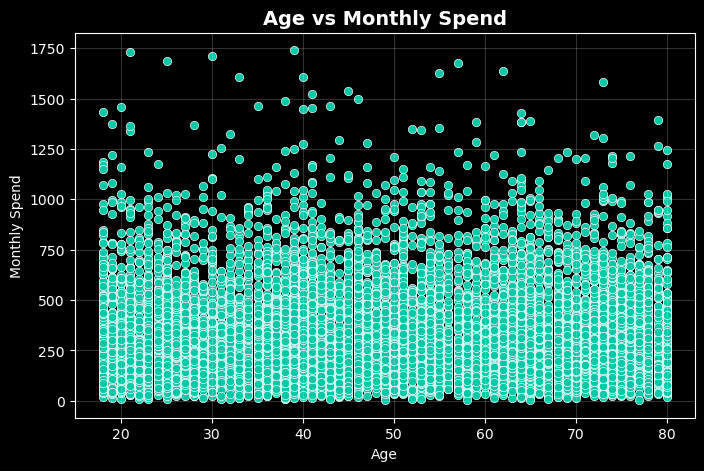

In [18]:
plt.figure(figsize=(8,5))
plt.style.use("dark_background")
sns.scatterplot(data=df, x="Age", y="MonthlySpend", color="#00C9A7")
plt.title("Age vs Monthly Spend", fontsize=14, weight='bold')
plt.xlabel("Age")
plt.ylabel("Monthly Spend")

plt.grid(alpha=0.2)
plt.show()

<div class="alert alert-block alert-success" 
     style="background-color:#edf7f0; 
            border-left:5px solid #22c55e; 
            padding:14px; 
            border-radius:8px;">

### Observation:
The scatterplot shows no strong linear relationship between age and monthly spending.  
Customer spending behavior appears to vary across all age groups.


## **KDE: Spending behavior by education level or marital status**

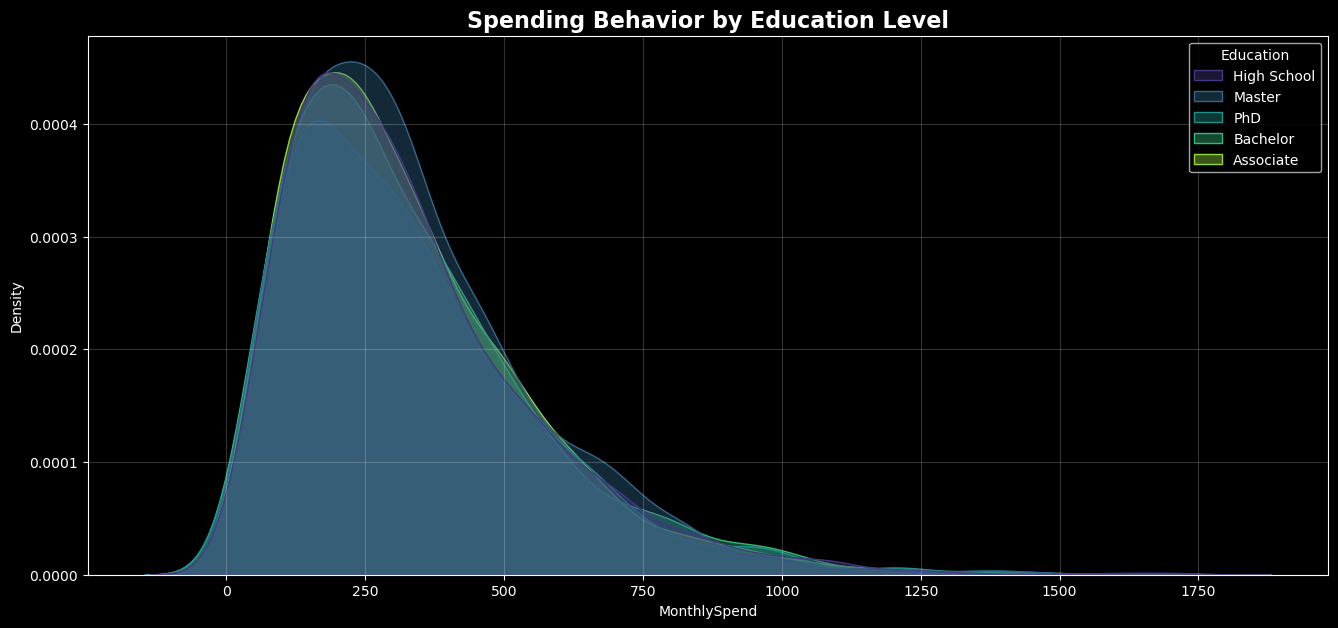

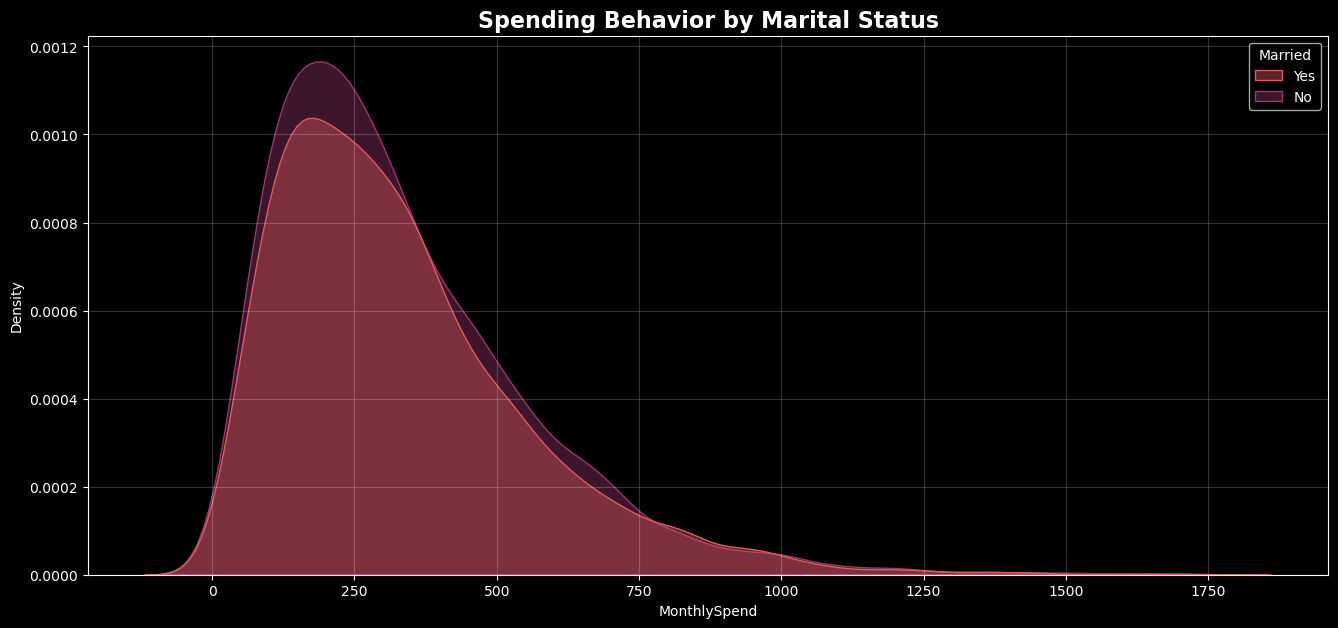

In [19]:
# KDE – Spending by education

plt.figure(figsize=(16,7))
plt.style.use("dark_background")
sns.kdeplot(data=df, x='MonthlySpend', hue='Education', fill=True, alpha=0.4, palette='viridis')
plt.title("Spending Behavior by Education Level", fontsize=16, color='white', weight='bold')
plt.grid(alpha=0.2)
plt.show()


# KDE – Spending by Marital Status

plt.figure(figsize=(16,7))
plt.style.use("dark_background")
sns.kdeplot(data=df, x='MonthlySpend', hue='Married', fill=True, alpha=0.4, palette='flare')
plt.title("Spending Behavior by Marital Status", fontsize=16, color='white', weight='bold')
plt.grid(alpha=0.2)
plt.show()

<div class="alert alert-block alert-success" 
     style="background-color:#edf7f0; 
            border-left:5px solid #22c55e; 
            padding:14px; 
            border-radius:8px;">

## KDE – Spending by education
### Observation:
Customers with higher education levels such as Master’s and PhD tend to show slightly higher spending concentrations compared to other education groups.


---


## KDE – Spending by education
### Observation:
The spending distribution for married and non-married customers is relatively similar, indicating limited variation in spending behavior based on marital status.


---



<div class="alert alert-block alert-info" 
     style="background-color:#eefbff; 
            border-left:5px solid #06b6d4; 
            padding:14px; 
            border-radius:8px;"> 

# **📊4: Bivariate Analysis**



## **Correlation matrix (numeric variables)**

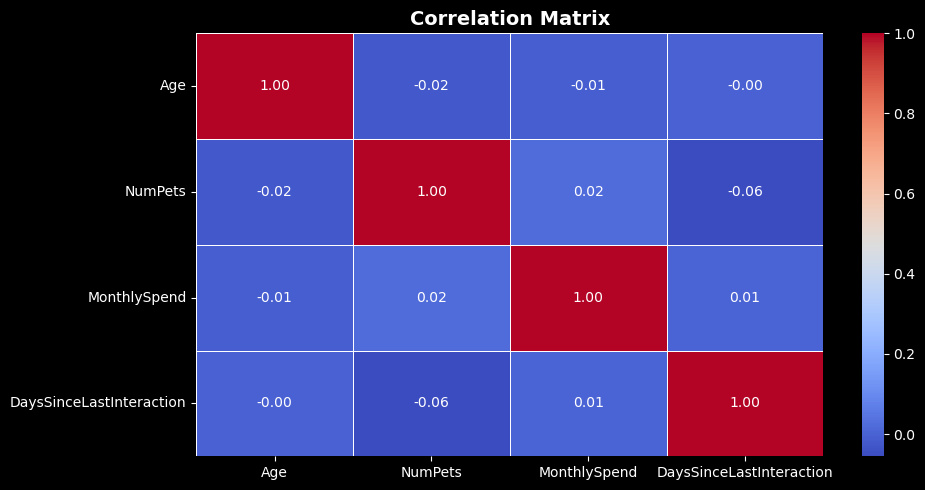

In [20]:
# Correlation matrix (numeric variables)

plt.figure(figsize=(10,5))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,annot=True,fmt=".2f",linewidths=0.5,cmap="coolwarm",cbar=True)

plt.title("Correlation Matrix", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success" 
     style="background-color:#edf7f0; 
            border-left:5px solid #22c55e; 
            padding:14px; 
            border-radius:8px;">

### Observation:
The correlation matrix indicates weak relationships among most numerical variables.  
No strong positive or negative correlations were observed in the dataset.


---

## **Crosstab of Gender vs Married**

Married       No   Yes
Gender                
Female      1797  1616
Male        1892  1899
Non-Binary  1894  1577
------------------------------------------------------------------------------------------------------------------------


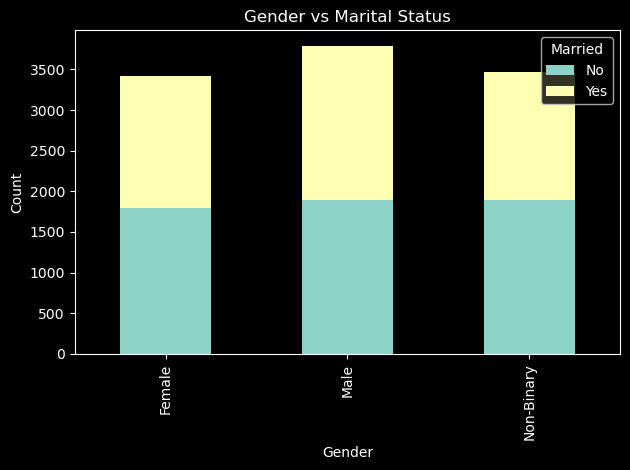

In [21]:
# Crosstab (Gender vs Married)
ct = pd.crosstab(df["Gender"], df["Married"])
print(ct)

print(40*"---")


ct.plot(kind="bar", stacked=True)
plt.title("Gender vs Marital Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success" 
     style="background-color:#edf7f0; 
            border-left:5px solid #22c55e; 
            padding:14px; 
            border-radius:8px;">
    
### Observation:
The stacked bar chart shows that marital status distribution is relatively balanced across gender categories, with no major imbalance observed.


---



## **Grouped stats: average MonthlySpend by State, Education, Gender**

In [22]:
# Average Spend by State
print("\n========== Average Spend by State ==========\n")
print(df.groupby("State")["MonthlySpend"].mean().sort_values(ascending=False).round(2))

print("\n" + "="*60 + "\n")

# Average Spend by Education
print("\n========== Average Spend by Education ==========\n")
print(df.groupby("Education")["MonthlySpend"].mean().sort_values(ascending=False).round(2))

print("\n" + "="*60 + "\n")

# Average Spend by Gender
print("\n========== Average Spend by Gender ==========\n")
print(df.groupby("Gender")["MonthlySpend"].mean().sort_values(ascending=False).round(2))


========== Average Spend by State ==========

State
Arizona       340.98
Ohio          339.71
California    338.69
Illinois      332.09
New York      331.66
Washington    328.96
Georgia       327.86
Florida       327.20
Colorado      322.58
Texas         319.01
Name: MonthlySpend, dtype: float64



========== Average Spend by Education ==========

Education
Master         333.76
High School    331.71
Bachelor       331.39
PhD            331.19
Associate      327.39
Name: MonthlySpend, dtype: float64



========== Average Spend by Gender ==========

Gender
Male          332.68
Female        330.87
Non-Binary    329.65
Name: MonthlySpend, dtype: float64


<div class="alert alert-block alert-info" 
     style="background-color:#eefbff; 
            border-left:5px solid #06b6d4; 
            padding:14px; 
            border-radius:8px;"> 

# **📊5: Formulate Hypothese**

## **1. Independent t-test (Gender vs Monthly Spend)**

### Hypotheses
* H₀ (Null Hypothesis): Average monthly spend of males and females is equal.
* H₁ (Alternative Hypothesis): Average monthly spend of males and females is different.

In [23]:
from scipy.stats import ttest_ind

male_spend = df[df['Gender'] == 'Male']['MonthlySpend']
female_spend = df[df['Gender'] == 'Female']['MonthlySpend']

t_stat, p_value = ttest_ind(male_spend, female_spend)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.33893314151833487
P-value: 0.7346699785398587


In [24]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


<div class="alert alert-block alert-success" 
     style="background-color:#edf7f0; 
            border-left:5px solid #22c55e; 
            padding:14px; 
            border-radius:8px;">

### Interpretation
Since the p-value is greater than 0.05, we fail to reject the null hypothesis.

This indicates that there is no statistically significant difference in average monthly spending between male and female customers.

## **2. Education Impact on Monthly Spend (One-Way ANOVA)**

### Hypotheses
* H₀: Average monthly spend is same across all education levels.
* H₁: At least one education group has different average spend.

In [25]:
from scipy.stats import f_oneway

high_school = df[df['Education'] == 'High School']['MonthlySpend']
bachelor = df[df['Education'] == 'Bachelor']['MonthlySpend']
master = df[df['Education'] == 'Master']['MonthlySpend']
phd = df[df['Education'] == 'PhD']['MonthlySpend']

f_stat, p_value = f_oneway(high_school, bachelor, master, phd)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.05978628906987674
P-value: 0.9808492827568338


In [26]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


<div class="alert alert-block alert-success" 
     style="background-color:#edf7f0; 
            border-left:5px solid #22c55e; 
            padding:14px; 
            border-radius:8px;">

### Interpretation

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.

This means there is no statistically significant difference in average monthly spending among different education levels.


## **3. Relationship Between Marital Status and Number of Pets (Chi-Square Test)**

## Hypotheses
* H₀: Marital status and number of pets are independent.
* H₁: Marital status and number of pets are related.

In [27]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Married'], df['NumPets'])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square value:", chi2)
print("P-value:", p_value)

Chi-square value: 177.63953668537033
P-value: 2.3957232932397494e-37


In [28]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


<div class="alert alert-block alert-success" 
     style="background-color:#edf7f0; 
            border-left:5px solid #22c55e; 
            padding:14px; 
            border-radius:8px;">

### Interpretation

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.

This suggests that marital status and number of pets owned are statistically independent.


## **4. Relationship Between Age and Customer Activity (Correlation Test)**

## Hypotheses
* H₀: No relationship between Age and DaysSinceLastInteraction.
* H₁: Relationship exists between Age and DaysSinceLastInteraction.

In [29]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Age'], df['DaysSinceLastInteraction'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.003970230104955045
P-value: 0.6816905437300954


In [30]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


<div class="alert alert-block alert-success" 
     style="background-color:#edf7f0; 
            border-left:5px solid #22c55e; 
            padding:14px; 
            border-radius:8px;">

### Interpretation

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.

This indicates that there is no statistically significant relationship between age and customer activity level.


## **5. State-wise Differences in Monthly Spend (One-Way ANOVA)**

## Hypotheses
* H₀: Average monthly spend is same across states.
* H₁: At least one state has different average spend.

In [31]:
from scipy.stats import f_oneway

state_groups = [group['MonthlySpend'].values for name, group in df.groupby('State')]

f_stat, p_value = f_oneway(*state_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.11837574679605
P-value: 0.3453340735204014


In [32]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


<div class="alert alert-block alert-success" 
     style="background-color:#edf7f0; 
            border-left:5px solid #22c55e; 
            padding:14px; 
            border-radius:8px;">

### Interpretation

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.

This means average monthly spending does not differ significantly across states.

<div class="alert alert-block alert-info" 
     style="background-color:#eefbff; 
            border-left:5px solid #06b6d4; 
            padding:14px; 
            border-radius:8px;"> 
    
# **📊6: Run Hypothesis Tests**

## Objective
The purpose of hypothesis testing is to validate whether the observed patterns in the dataset are statistically significant or occurred by chance.

---

# 1. Gender vs Monthly Spend:

### Business Question




Do males and females spend differently?

### Null Hypothesis (H₀)
Male and female customers have the same average monthly spend.

### Alternative Hypothesis (H₁)
Male and female customers have different average monthly spend.

### Statistical Test Used
Independent t-test

### Why this Test?
The t-test is appropriate because:
- Gender is a categorical variable with two groups
- MonthlySpend is a numerical variable
- We want to compare the mean spending between two groups

### Assumptions Checked
- Observations are independent
- Spending data is approximately normally distributed
- Variance between groups is similar

### Interpretation Rule
- If p-value < 0.05 → Reject H₀
- If p-value > 0.05 → Fail to reject H₀

---

# 2. Education vs Monthly Spend:

### Business Question
Does education level impact average monthly spend?

### Null Hypothesis (H₀)
All education groups have the same average monthly spend.

### Alternative Hypothesis (H₁)
At least one education group has a different average monthly spend.

### Statistical Test Used
One-Way ANOVA

### Why this Test?
ANOVA is used because:
- Education contains multiple categories
- MonthlySpend is numerical
- We are comparing means across more than two groups

### Assumptions Checked
- Independent observations
- Normal distribution within groups
- Homogeneity of variance

### Interpretation Rule
- If p-value < 0.05 → Reject H₀
- If p-value > 0.05 → Fail to reject H₀

---

# 3. Age vs Customer Activity:

### Business Question
Are older people less active?

### Null Hypothesis (H₀)
There is no relationship between age and days since last interaction.

### Alternative Hypothesis (H₁)
There is a significant relationship between age and days since last interaction.

### Statistical Test Used
Pearson Correlation

### Why this Test?
Correlation is used because:
- Both Age and DaysSinceLastInteraction are numerical variables
- We want to measure the strength and direction of relationship

### Assumptions Checked
- Linear relationship between variables
- No major outliers
- Approximately normal distribution

### Interpretation Rule
- If p-value < 0.05 → Significant relationship exists
- If p-value > 0.05 → No significant relationship exists

### Correlation Interpretation
- Positive correlation → Inactivity increases with age
- Negative correlation → Older customers are more active

---

# 4. State vs Monthly Spend:

### Business Question
Does state-wise spending vary significantly?

### Null Hypothesis (H₀)
All states have the same average monthly spend.

### Alternative Hypothesis (H₁)
At least one state has a different average monthly spend.

### Statistical Test Used
One-Way ANOVA

### Why this Test?
ANOVA is appropriate because:
- State is a categorical variable with multiple groups
- MonthlySpend is numerical
- Mean spending is being compared across several states

### Assumptions Checked
- Independent observations
- Normal distribution within groups
- Equal variance across groups

### Interpretation Rule
- If p-value < 0.05 → Reject H₀
- If p-value > 0.05 → Fail to reject H₀

---

# Conclusion

Hypothesis testing helps determine whether customer behavior patterns observed in the dataset are statistically significant.  
The results support data-driven decision-making by validating relationships between demographics, engagement, and spending behavior.

<div class="alert alert-block alert-info" 
     style="background-color:#eefbff; 
            border-left:5px solid #06b6d4; 
            padding:14px; 
            border-radius:8px;"> 

# **📊 7: Business Insights**

## Business Insights

Based on exploratory data analysis and hypothesis testing, the following business insights were identified from the customer dataset.

---

### 1. Customers with Master’s Degrees Have the Highest Average Spending

Customers with a Master’s degree recorded the highest average monthly spending of approximately **334**,

while customers with an Associate degree showed the lowest average spending at around **328**.

#### Business Recommendation
The company can target highly educated customers with premium products, loyalty programs, and personalized offers.

---

### 2. Gender Has Minimal Impact on Spending Behavior

The average monthly spending among genders was very similar:
- Male customers: **333**

- Female customers: **331**

- Non-Binary customers: **330**

The independent t-test produced a p-value of **0.734**, which indicates that the difference is not statistically significant.

#### Business Recommendation
Instead of gender-based segmentation, the business should focus more on behavioral and demographic factors such as engagement and education.

---

### 3. Arizona Customers Show the Highest Average Spending

Among all states, customers from **Arizona** recorded the highest average monthly spending of approximately **341**,

while **Texas** customers showed the lowest average spending at around **320**.

#### Business Recommendation
The company should prioritize high-performing states such as Arizona and California for targeted marketing campaigns and customer retention strategies.

---

### 4. Age Has Almost No Relationship with Customer Activity

The correlation between Age and DaysSinceLastInteraction was approximately **-0.004**, with a p-value of **0.682**.  
This indicates that there is no significant relationship between customer age and activity level.

#### Business Recommendation
Customer engagement strategies should focus more on behavioral patterns rather than age alone.

---

### 5. Customer Engagement Opportunities Exist Across All Segments

The average DaysSinceLastInteraction was approximately **538 days**, indicating that many customers have not interacted with the company recently.

#### Business Recommendation
The business can improve customer retention through re-engagement campaigns, personalized emails, discount offers, and loyalty rewards.

---

# ✅ Final Conclusion

The statistical investigation revealed that:
- Education level has limited influence on customer spending behavior
- State-wise spending variation is relatively small
- Gender and age have minimal statistical impact on spending and engagement
- Customer inactivity is a major business concern
- Behavioral targeting and customer engagement strategies may provide better business outcomes than demographic segmentation

</div>